Unused. I do not believe this experiment was successful or even correct.

PCIC + RLCT estimation via subsample log-evidence scaling.

For each tilting parameter λ the Real Log Canonical Threshold (RLCT) is estimated
by fitting the asymptotic scaling

    -log Z(n)  ≈  RLCT · log n  +  const

where  Z(n) = ∫ exp(Σ_i w_i^λ log h(y_i|θ)) π(θ) dθ.

The model is a 2-parameter linear-Gaussian regression with a conjugate N(0, I) prior.
Every quantity - log Z, PCIC, WAIC and generalisation error - is computed in
closed form (no MCMC required).

Analytic posterior:
    Λ = Φᵀ W Φ / σ²  +  I₂         (precision,   W = diag(w_i^λ))
    μ = Λ⁻¹ Φᵀ W y / σ²            (mean)
    Σ = Λ⁻¹                          (covariance)

Analytic predictive for observation i:
    f_i = φᵢᵀθ ~ N(μ_f, v_f),  μ_f = φᵢᵀμ,  v_f = φᵢᵀΣφᵢ
    y_i | data ~ N(μ_f, σ² + v_f)

Analytic posterior variance of log h(y_i|θ):
    Var_pos[log h] = v_f · (v_f + 2(μ_f - y_i)²) / (2σ⁴)

In [33]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

np.random.seed(42)

# Data
n_train     = 500
sigma_noise = 0.25

X_train = np.random.normal(0.0, 1.0, n_train)
Y_train = np.sinc(X_train) + np.random.normal(0, sigma_noise, n_train)

n_test  = 500
X_test  = np.random.normal(0.5, 0.3, n_test)
Y_test  = np.sinc(X_test)  + np.random.normal(0, sigma_noise, n_test)

In [34]:
# ── Importance weights  w_i = p_test(x_i) / p_train(x_i) ────────────────────
def compute_weights(X, mu_tr=0.0, s_tr=1.0, mu_te=0.5, s_te=0.3):
    return norm.pdf(X, mu_te, s_te) / norm.pdf(X, mu_tr, s_tr)

weights = compute_weights(X_train)

# ── Analytic conjugate posterior ──────────────────────────────────────────────
def conjugate_posterior(X, Y, w, lam, sigma=sigma_noise):
    n   = len(X)
    Phi = np.column_stack([np.ones(n), X])
    Wl  = w ** lam
    Lam   = (Phi.T * Wl) @ Phi / sigma**2 + np.eye(2)
    b     = (Phi.T * Wl) @ Y   / sigma**2
    Sigma = np.linalg.inv(Lam)
    mu    = Sigma @ b
    return mu, Sigma, Lam

# ── Analytic log marginal evidence (FIXED: added 0.5*sum(log(Wl))) ────────────
def log_evidence(X, Y, w, lam, sigma=sigma_noise):
    n   = len(X)
    Phi = np.column_stack([np.ones(n), X])
    Wl  = w ** lam
    Lam = (Phi.T * Wl) @ Phi / sigma**2 + np.eye(2)
    b   = (Phi.T * Wl) @ Y   / sigma**2
    return (
        -n / 2 * np.log(2 * np.pi * sigma**2)
        + 0.5 * np.sum(np.log(Wl))          # ← missing normalisation term
        - (Wl @ Y**2) / (2 * sigma**2)
        + 0.5 * b @ np.linalg.solve(Lam, b)
        - 0.5 * np.linalg.slogdet(Lam)[1]
    )

# ── Per-observation predictive quantities ─────────────────────────────────────
def predictive_stats(phi_i, mu, Sigma, y_i, sigma=sigma_noise):
    mu_f      = phi_i @ mu
    v_f       = phi_i @ Sigma @ phi_i
    log_pred  = norm.logpdf(y_i, mu_f, np.sqrt(sigma**2 + v_f))
    var_log_h = v_f * (v_f + 2 * (mu_f - y_i)**2) / (2 * sigma**4)
    return log_pred, var_log_h

# ── Analytic PCIC ─────────────────────────────────────────────────────────────
def pcic_analytic(X, Y, w, lam, sigma=sigma_noise):
    mu, Sigma, _ = conjugate_posterior(X, Y, w, lam, sigma)
    n   = len(X)
    t1  = 0.0
    t2  = 0.0
    for i in range(n):
        phi_i             = np.array([1.0, X[i]])
        log_pred, var_lh  = predictive_stats(phi_i, mu, Sigma, Y[i], sigma)
        t1 -= w[i] * log_pred
        t2 += w[i] * (w[i]**lam) * var_lh
    return (t1 + t2) / n, t1, t2

# ── Analytic WAIC ─────────────────────────────────────────────────────────────
def waic_analytic(X, Y, w, lam, sigma=sigma_noise):
    mu, Sigma, _ = conjugate_posterior(X, Y, w, lam, sigma)
    total = 0.0
    for i in range(len(X)):
        phi_i            = np.array([1.0, X[i]])
        log_pred, var_lh = predictive_stats(phi_i, mu, Sigma, Y[i], sigma)
        total += var_lh - log_pred
    return total

# ── Analytic generalisation error on test set ─────────────────────────────────
def gen_error_analytic(X_te, Y_te, X_tr, Y_tr, w_tr, lam, sigma=sigma_noise):
    mu, Sigma, _ = conjugate_posterior(X_tr, Y_tr, w_tr, lam, sigma)
    ge = 0.0
    for i in range(len(X_te)):
        phi_i       = np.array([1.0, X_te[i]])
        log_pred, _ = predictive_stats(phi_i, mu, Sigma, Y_te[i], sigma)
        ge         -= log_pred
    return ge / len(X_te)

# ── RLCT estimation (stable two‑step procedure) ───────────────────────────────
def estimate_rlct(X, Y, w, lam, subsample_sizes, n_repeats=200, sigma=sigma_noise):
    mean_neg_logZ = np.zeros(len(subsample_sizes))
    mean_S = np.zeros(len(subsample_sizes))

    for k, n_sub in enumerate(subsample_sizes):
        neg_logZ_vals = []
        S_vals = []
        for _ in range(n_repeats):
            idx = np.random.choice(len(X), n_sub, replace=False)
            Xsub, Ysub, wsub = X[idx], Y[idx], w[idx]

            # --- log evidence ---
            neg_logZ_vals.append(-log_evidence(Xsub, Ysub, wsub, lam, sigma))

            # --- training loss S for this subset ---
            n = len(Xsub)
            Phi = np.column_stack([np.ones(n), Xsub])
            Wl = wsub ** lam
            # weighted MLE
            theta_wls = np.linalg.lstsq(Phi.T @ (Wl[:, None] * Phi),
                                        Phi.T @ (Wl * Ysub), rcond=None)[0]
            rss = np.sum(Wl * (Ysub - Phi @ theta_wls) ** 2)
            S = (0.5 * np.log(2 * np.pi * sigma**2)
                 - 0.5 * np.mean(np.log(Wl))
                 + 0.5 * rss / (n * sigma**2))
            S_vals.append(S)

        mean_neg_logZ[k] = np.mean(neg_logZ_vals)
        mean_S[k] = np.mean(S_vals)

    n_arr = subsample_sizes.astype(float)
    residual = mean_neg_logZ - n_arr * mean_S   # subtract exact O(n) term

    # fit residual = λ * log n + const
    log_n = np.log(n_arr)
    A = np.column_stack([log_n, np.ones_like(n_arr)])
    coeffs, _, _, _ = np.linalg.lstsq(A, residual, rcond=None)
    rlct = max(coeffs[0], 0.0)
    return rlct, -mean_neg_logZ   # return mean log Z (positive sign for plotting)

In [37]:
# ── Grid and computation ──────────────────────────────────────────────────────
lambda_values   = np.linspace(0.0, 1.6, 60)
# use a finer range of subsample sizes, well spread
subsample_sizes = np.array([30, 60, 100, 150, 200, 260, 320, 390, 470])

print("Computing RLCT, PCIC, WAIC, gen error for each lambda ...")

rlct_values      = []
log_Z_curves     = []
pcic_values      = []
waic_values      = []
gen_error_values = []

for lam in lambda_values:
    rlct, lz = estimate_rlct(X_train, Y_train, weights, lam,
                             subsample_sizes, n_repeats=400)
    rlct_values.append(rlct)
    log_Z_curves.append(lz)

    pcic, _, _  = pcic_analytic(X_train, Y_train, weights, lam)
    pcic_values.append(pcic)
    waic_values.append(waic_analytic(X_train, Y_train, weights, lam))
    gen_error_values.append(
        gen_error_analytic(X_test, Y_test, X_train, Y_train, weights, lam)
    )
    print(f"  lam={lam:.3f}  RLCT={rlct:.4f}  PCIC={pcic:.4f}  gen={gen_error_values[-1]:.4f}")

rlct_values      = np.array(rlct_values)
pcic_values      = np.array(pcic_values)
waic_values      = np.array(waic_values)
gen_error_values = np.array(gen_error_values)

best_pcic = lambda_values[np.argmin(pcic_values)]
best_true = lambda_values[np.argmin(gen_error_values)]

print(f"\nBest λ by PCIC: {best_pcic:.3f}")
print(f"Best λ by test error: {best_true:.3f}")

Computing RLCT, PCIC, WAIC, gen error for each lambda ...
  lam=0.000  RLCT=1.0074  PCIC=0.9926  gen=1.0166
  lam=0.027  RLCT=1.0020  PCIC=0.8562  gen=0.8875
  lam=0.054  RLCT=1.0009  PCIC=0.7341  gen=0.7696
  lam=0.081  RLCT=1.0033  PCIC=0.6270  gen=0.6648
  lam=0.108  RLCT=1.0071  PCIC=0.5349  gen=0.5736
  lam=0.136  RLCT=1.0048  PCIC=0.4566  gen=0.4953
  lam=0.163  RLCT=1.0012  PCIC=0.3906  gen=0.4287
  lam=0.190  RLCT=1.0077  PCIC=0.3351  gen=0.3722
  lam=0.217  RLCT=1.0076  PCIC=0.2886  gen=0.3245
  lam=0.244  RLCT=1.0086  PCIC=0.2497  gen=0.2842
  lam=0.271  RLCT=1.0072  PCIC=0.2171  gen=0.2501
  lam=0.298  RLCT=1.0098  PCIC=0.1899  gen=0.2213
  lam=0.325  RLCT=1.0042  PCIC=0.1671  gen=0.1969
  lam=0.353  RLCT=1.0080  PCIC=0.1479  gen=0.1762
  lam=0.380  RLCT=1.0078  PCIC=0.1319  gen=0.1587
  lam=0.407  RLCT=1.0119  PCIC=0.1184  gen=0.1438
  lam=0.434  RLCT=1.0122  PCIC=0.1071  gen=0.1311
  lam=0.461  RLCT=1.0104  PCIC=0.0976  gen=0.1202
  lam=0.488  RLCT=1.0092  PCIC=0.0896  gen

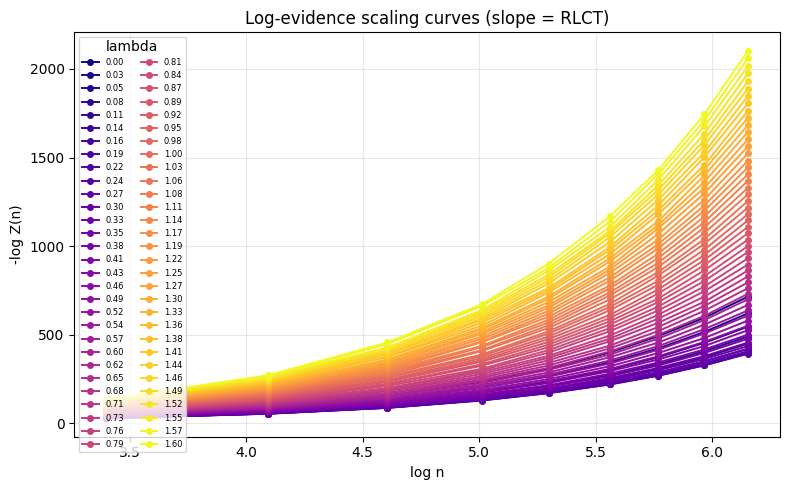

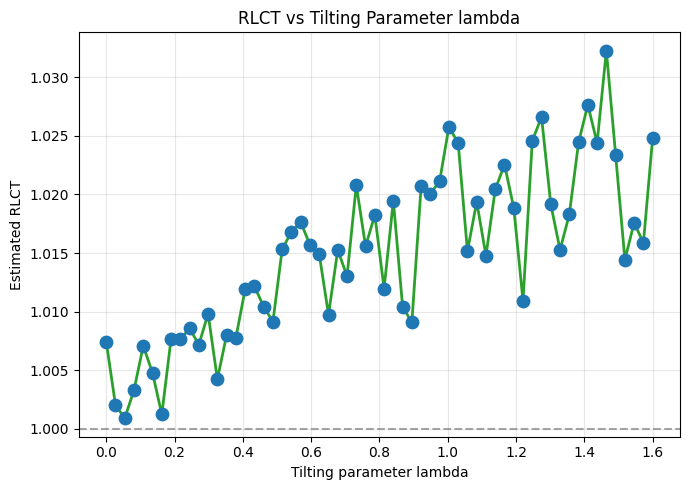

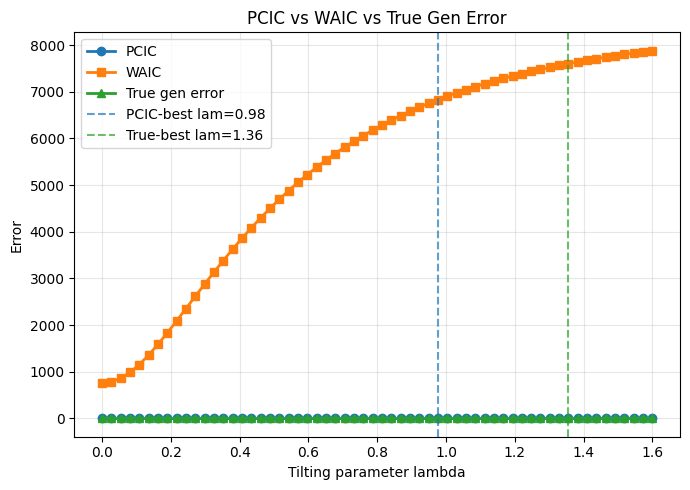

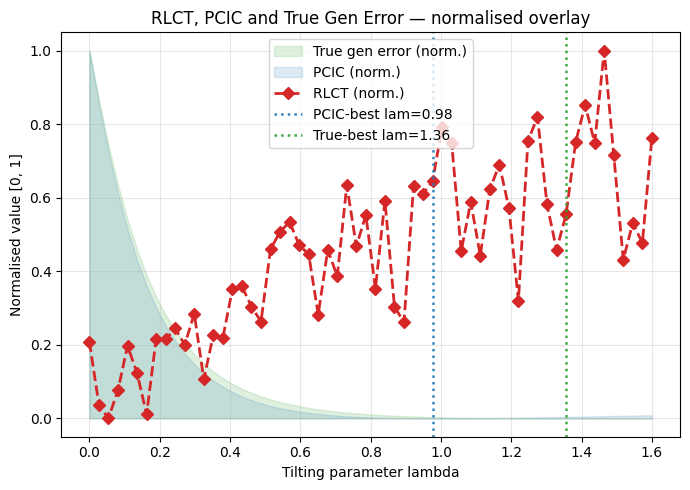

: 

In [ ]:
# Plots (separate figures for clarity)
cmap = plt.cm.plasma

# Figure 1: log-evidence scaling curves
plt.figure(figsize=(8, 5))
for j, lam in enumerate(lambda_values):
    col = cmap(j / max(len(lambda_values) - 1, 1))
    plt.plot(np.log(subsample_sizes), -log_Z_curves[j],
             'o-', color=col, linewidth=1.4, markersize=4, label=f'{lam:.2f}')
plt.xlabel('log n')
plt.ylabel('-log Z(n)')
plt.title('Log-evidence scaling curves (slope = RLCT)')
plt.grid(alpha=0.3)
plt.legend(title='lambda', fontsize=6, ncol=2, loc='upper left')
plt.tight_layout()

# RLCT vs lambda
plt.figure(figsize=(7, 5))
plt.scatter(lambda_values, rlct_values, s=80, zorder=3)
plt.plot(lambda_values, rlct_values, '-', color='C2', linewidth=2.0, zorder=2)
plt.axhline(1.0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7,
            label='d/2 = 1  (regular)')
plt.xlabel('Tilting parameter lambda')
plt.ylabel('Estimated RLCT')
plt.title('RLCT vs Tilting Parameter lambda')
plt.grid(alpha=0.3)
plt.tight_layout()

# Figure 3: PCIC / WAIC / gen-error
plt.figure(figsize=(7, 5))
plt.plot(lambda_values, pcic_values,      'o-', label='PCIC',           linewidth=2)
plt.plot(lambda_values, waic_values,      's-', label='WAIC',           linewidth=2)
plt.plot(lambda_values, gen_error_values, '^-', label='True gen error', linewidth=2)
plt.axvline(best_pcic, color='C0', linestyle='--', alpha=0.7,
            label=f'PCIC-best lam={best_pcic:.2f}')
plt.axvline(best_true, color='C2', linestyle='--', alpha=0.7,
            label=f'True-best lam={best_true:.2f}')
plt.xlabel('Tilting parameter lambda')
plt.ylabel('Error')
plt.title('PCIC vs WAIC vs True Gen Error')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Figure 4: Normalised overlay
def norm01(v):
    v   = np.asarray(v, float)
    rng = v.max() - v.min()
    return (v - v.min()) / (rng if rng > 0 else 1.0)

plt.figure(figsize=(7, 5))
plt.fill_between(lambda_values, norm01(gen_error_values),
                 alpha=0.15, color='C2', label='True gen error (norm.)')
plt.fill_between(lambda_values, norm01(pcic_values),
                 alpha=0.15, color='C0', label='PCIC (norm.)')
plt.plot(lambda_values, norm01(rlct_values), 'D--',
         color='C3', linewidth=2, markersize=6, label='RLCT (norm.)')
plt.axvline(best_pcic, color='C0', linestyle=':', linewidth=1.8, alpha=0.9,
            label=f'PCIC-best lam={best_pcic:.2f}')
plt.axvline(best_true, color='C2', linestyle=':', linewidth=1.8, alpha=0.9,
            label=f'True-best lam={best_true:.2f}')
plt.xlabel('Tilting parameter lambda')
plt.ylabel('Normalised value [0, 1]')
plt.title('RLCT, PCIC and True Gen Error — normalised overlay')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()

# # RLCT table as a DataFrame for clearer display
# import pandas as pd
# df_rlct = pd.DataFrame({'lambda': lambda_values, 'RLCT': rlct_values})
# display(df_rlct.style.format({'lambda':'{:.2f}','RLCT':'{:.4f}'}))

# print("\n-- RLCT / PCIC summary --")
# print(f"  {'lam':>6}   {'RLCT':>8}   {'PCIC':>8}   {'Gen err':>8}")
# print("  " + "-"*40)
# for lam, rlct, pcic, ge in zip(lambda_values, rlct_values, pcic_values, gen_error_values):
#     print(f"  {lam:6.3f}   {rlct:8.4f}   {pcic:8.4f}   {ge:8.4f}")
# print(f"\n  Best lambda by PCIC:             {best_pcic:.2f}")
# print(f"  Best lambda by true gen error:   {best_true:.2f}")